In [54]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Ingeniería de características


## Cargar datos

In [55]:
df = pd.read_csv("../data/processed/olist_eda.csv")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 118434 entries, 0 to 118433
Data columns (total 7 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       118434 non-null  str    
 1   customer_id                    118434 non-null  str    
 2   order_purchase_timestamp       118434 non-null  str    
 3   customer_unique_id             118434 non-null  str    
 4   order_item_id                  117604 non-null  float64
 5   product_category_name_english  115881 non-null  str    
 6   payment_value                  118431 non-null  float64
dtypes: float64(2), str(5)
memory usage: 6.3 MB


## Análisis de outliers

In [56]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
order_item_id,117604.0,1.195920,0.697721,1.0,1.00,1.0,1.000,21.00
payment_value,118431.0,172.849395,268.259831,0.0,60.86,108.2,189.245,13664.08


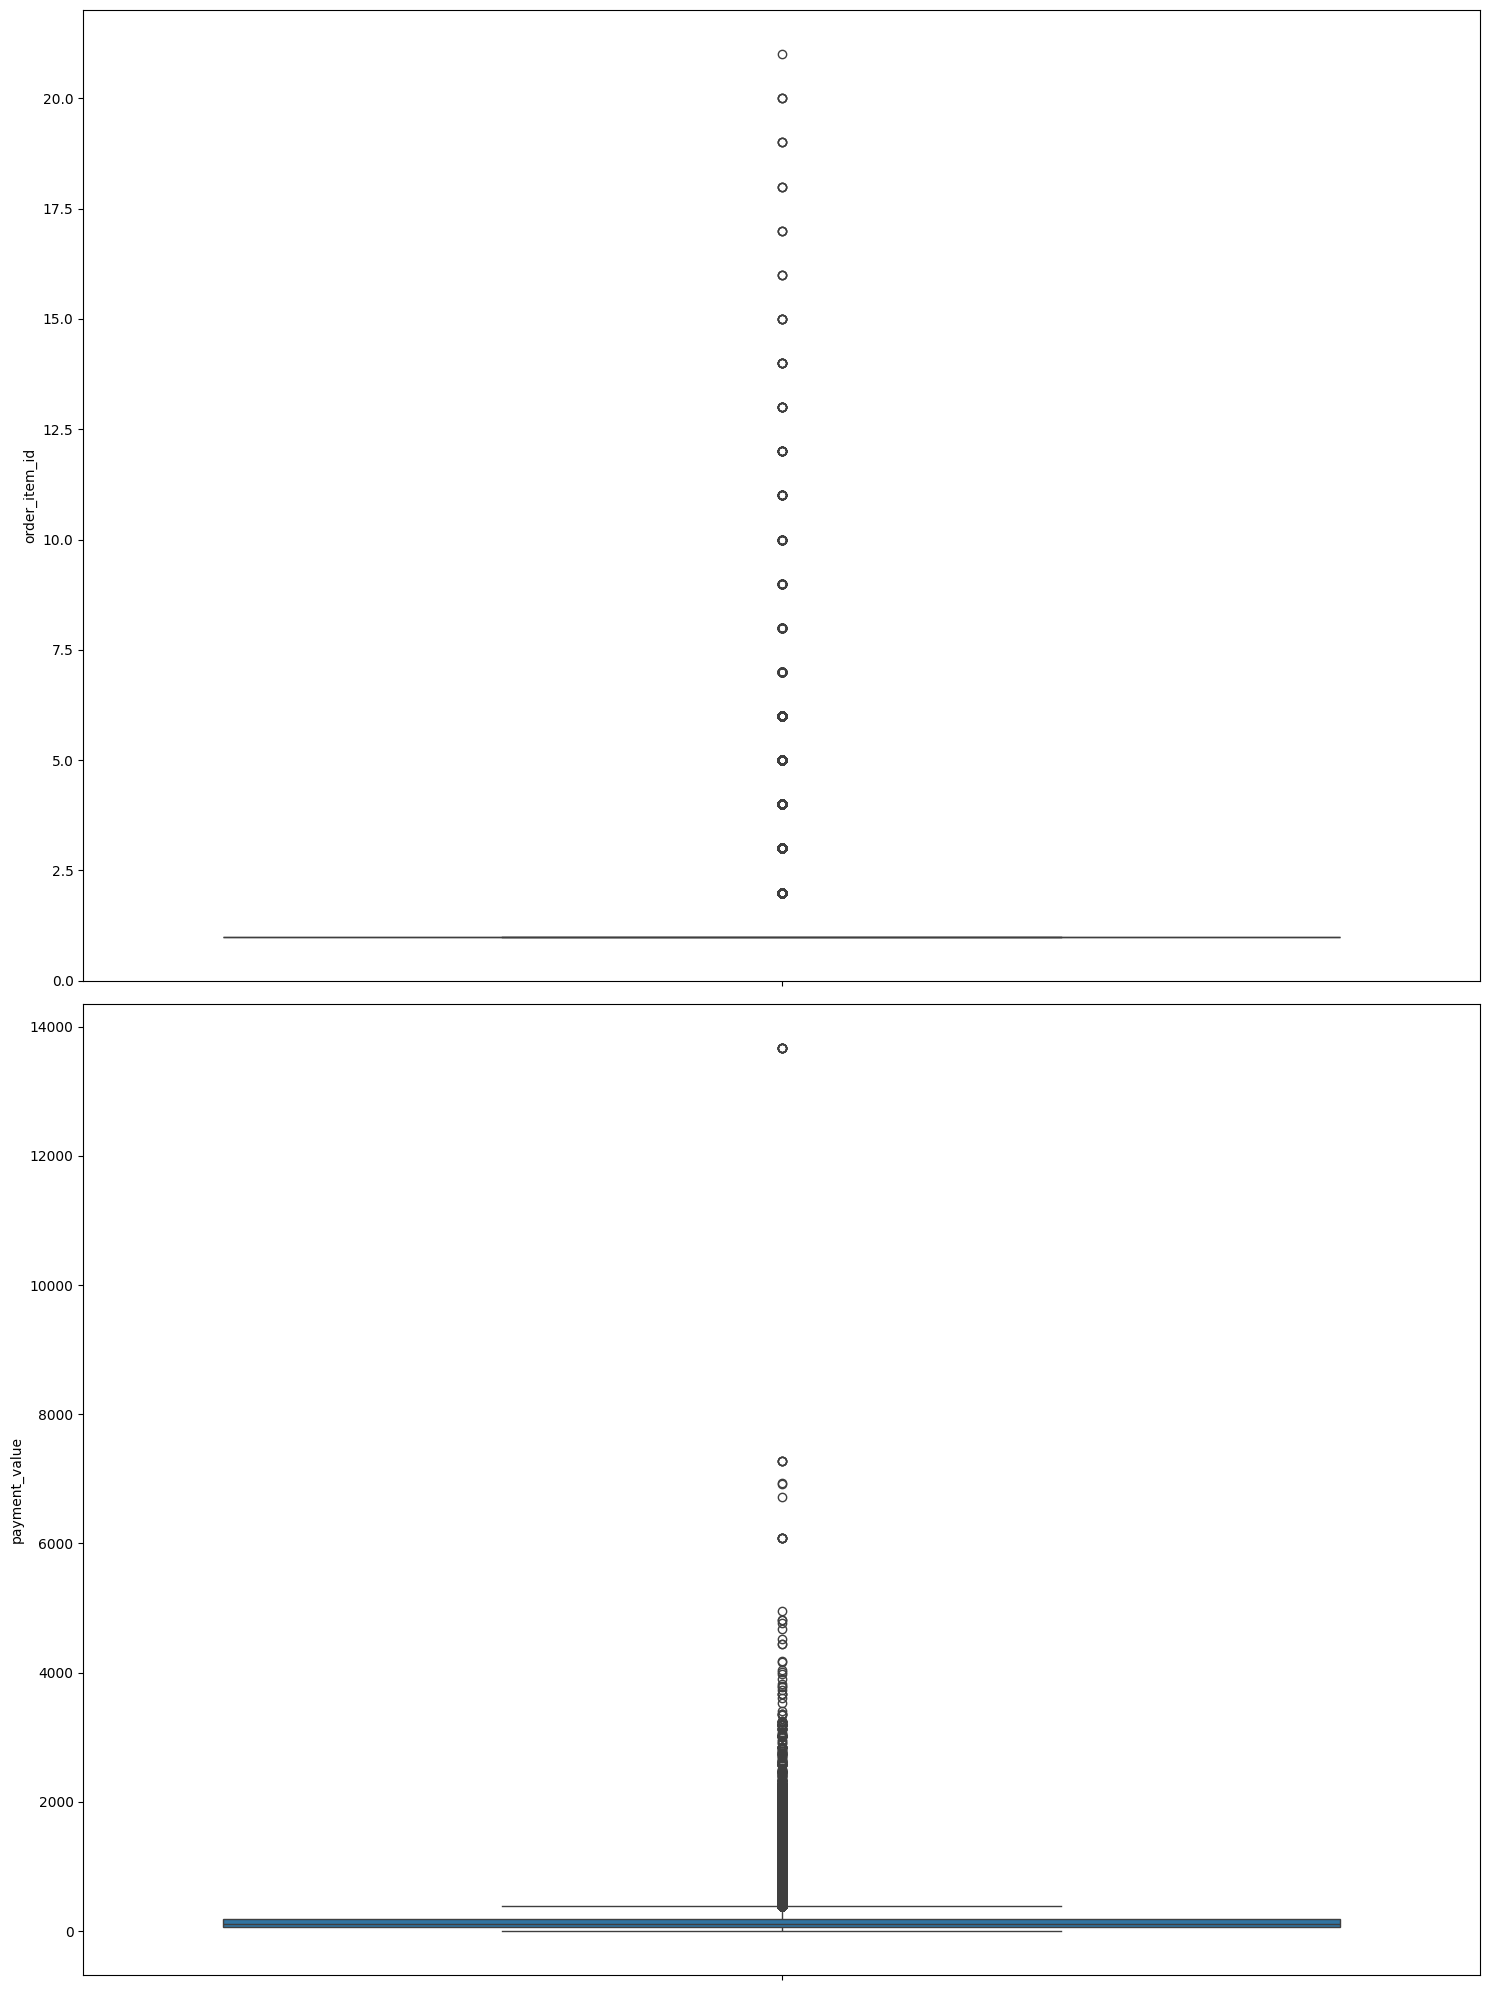

In [57]:
fig, axis = plt.subplots(2, 1, figsize=(15, 20))

sns.boxplot(ax=axis[0], data=df, y="order_item_id")
sns.boxplot(ax=axis[1], data=df, y="payment_value")

plt.tight_layout()

##### Observaciones:
> -  En lo observado con el análisis univariante, decido manetener los valores atipicos porqué existe una relacion en el aumento del precio con la cantidad de productos agrupados en una misma orden.

#### Análisis de valores faltantes

In [58]:
df.shape[1]

7

In [59]:
df.isnull().sum().sort_values(ascending=False) / len(df)

product_category_name_english    0.021556
order_item_id                    0.007008
payment_value                    0.000025
order_purchase_timestamp         0.000000
customer_id                      0.000000
order_id                         0.000000
customer_unique_id               0.000000
dtype: float64

In [60]:
df[df["product_category_name_english"].isnull()]

,order_id,customer_id,order_purchase_timestamp,customer_unique_id,order_item_id,product_category_name_english,payment_value
8,136cce7faa42fdb2cefd53fdc79a6098,ed0271e0b7da060a393796590e7b737a,2017-04-11 12:22:08,36edbb3fb164b1f16485364b6fb04c73,1.0,NaN,65.95
129,bfe42c22ecbf90bc9f35cf591270b6a7,803ac05904124294f8767894d6da532b,2018-01-27 22:04:34,34c58672601f2c6d29db7efd1f6bf958,1.0,NaN,42.40
221,58ac1947c1a9067b9f416cba6d844a3f,ee8e1d37f563ecc11cc4dcb4dfd794c2,2017-09-13 09:18:50,5cbf29b2dcf212a6a5d864b887238c72,1.0,NaN,124.16
274,e22b71f6e4a481445ec4527cb4c405f7,1faf89c8f142db3fca6cf314c51a37b6,2017-04-22 13:48:18,1268b060098ed3f22c2e7c34cc72a1a8,1.0,NaN,34.24
316,a094215e786240fcfefb83d18036a1cd,86acfb656743da0c113d176832c9d535,2018-02-08 18:56:45,f5cb81f98962f7504bef1e75579b6dff,1.0,NaN,132.05
...,...,...,...,...,...,...,...
118205,aaab15da689073f8f9aa978a390a69d1,df20748206e4b865b2f14a5eabbfcf34,2018-01-16 14:27:59,a33e0969408919ba06779f497ead93ec,NaN,NaN,210.09
118237,3a3cddda5a7c27851bd96c3313412840,0b0d6095c5555fe083844281f6b093bb,2018-08-31 16:13:44,e90598185d2427a35e32ef241a5c04aa,NaN,NaN,63.89
118330,a89abace0dcc01eeb267a9660b5ac126,2f0524a7b1b3845a1a57fcf3910c4333,2018-09-06 18:45:47,d05c44a138277ad325d915c6b7ccbcdf,NaN,NaN,107.13
118331,a69ba794cc7deb415c3e15a0a3877e69,726f0894b5becdf952ea537d5266e543,2017-08-23 16:28:04,e72a90a2b29fe1a8795b284aaaa3246f,NaN,NaN,195.91


In [61]:
df.dropna(inplace=True)
df.isnull().sum()

order_id                         0
customer_id                      0
order_purchase_timestamp         0
customer_unique_id               0
order_item_id                    0
product_category_name_english    0
payment_value                    0
dtype: int64

In [62]:
df["product_category_number"], product_category = pd.factorize(df["product_category_name_english"])
category_map = dict(enumerate(product_category))
category_map

{0: 'housewares',
 1: 'perfumery',
 2: 'auto',
 3: 'pet_shop',
 4: 'stationery',
 5: 'furniture_decor',
 6: 'office_furniture',
 7: 'garden_tools',
 8: 'computers_accessories',
 9: 'bed_bath_table',
 10: 'toys',
 11: 'construction_tools_construction',
 12: 'telephony',
 13: 'health_beauty',
 14: 'electronics',
 15: 'baby',
 16: 'cool_stuff',
 17: 'watches_gifts',
 18: 'air_conditioning',
 19: 'sports_leisure',
 20: 'books_general_interest',
 21: 'small_appliances',
 22: 'food',
 23: 'luggage_accessories',
 24: 'fashion_underwear_beach',
 25: 'christmas_supplies',
 26: 'fashion_bags_accessories',
 27: 'musical_instruments',
 28: 'construction_tools_lights',
 29: 'books_technical',
 30: 'costruction_tools_garden',
 31: 'home_appliances',
 32: 'market_place',
 33: 'agro_industry_and_commerce',
 34: 'party_supplies',
 35: 'home_confort',
 36: 'cds_dvds_musicals',
 37: 'industry_commerce_and_business',
 38: 'consoles_games',
 39: 'furniture_bedroom',
 40: 'construction_tools_safety',
 41: '

In [63]:
# Convertimos la columna a formato fecha
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])

In [64]:
# Extraemos información valiosa
df['month'] = df['order_purchase_timestamp'].dt.month
df['day_of_week'] = df['order_purchase_timestamp'].dt.weekday  # 0=Lunes, 6=Domingo
df['hour'] = df['order_purchase_timestamp'].dt.hour

## Escalado

### StandardScaler

In [65]:
df.columns

Index(['order_id', 'customer_id', 'order_purchase_timestamp',
       'customer_unique_id', 'order_item_id', 'product_category_name_english',
       'payment_value', 'product_category_number', 'month', 'day_of_week',
       'hour'],
      dtype='str')

In [66]:
X_clustering = df[[ "product_category_number", "payment_value", "month", "day_of_week", "hour"]]
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_clustering)

## Modelado

### KMeans Clustering

In [67]:
model_kmeans = KMeans(n_clusters=4, init="k-means++", n_init=10, random_state=42)

#Creo una variable para los diferentes clusters
df["customer_type"] = model_kmeans.fit_predict(X_scaled)

c:\Users\Usuario\miniconda3\envs\env_commerce_py313\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


In [68]:
customer_profile = df.groupby("customer_type")[["month", "day_of_week", "hour"]].mean()
customer_profile['customers_count'] = df['customer_type'].value_counts()
customer_profile

,month,day_of_week,hour,customers_count
customer_type,,,,
0,4.325320,4.536114,14.842031,37520
1,6.033535,2.732994,14.688210,9423
2,9.780220,2.682374,14.632793,34166
3,4.193419,0.878024,14.828986,34769


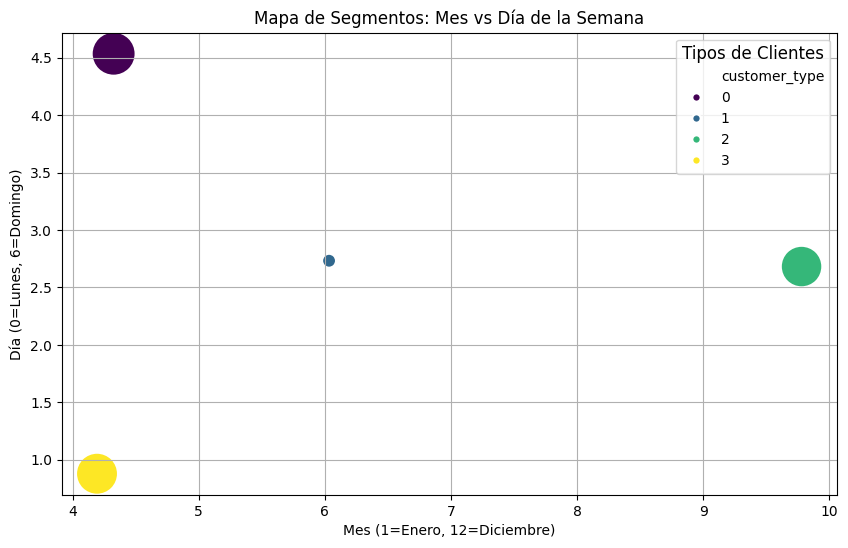

In [69]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=customer_profile, x='month', y='day_of_week', size='customers_count', hue="customer_type", palette='viridis', sizes=(100, 1000), legend="full")
plt.title('Mapa de Segmentos: Mes vs Día de la Semana')
plt.xlabel('Mes (1=Enero, 12=Diciembre)')
plt.ylabel('Día (0=Lunes, 6=Domingo)')
plt.grid(True)
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles[0:5], labels[0:5], title='Tipos de Clientes', title_fontsize='12', loc='upper right')

#### Observaciones:
> - La grafica presenta una distribucion de clusters bien diferenciada, indica que el número de clusters en los que se ha agrupado a los clientes es el correcto.
> - El primero grupo, `cluster 0`, representa a los clientes que efectuan compras sobre el mes de abril los jueves.
> - El Grupo minoritario en azul `cluster 1`, representa los clientes que suelen hacer compras en junio los martes.
> - `El cluster 2` en verde, representa los clientes que realizan compras a finales de septiembre los martes.
> - Por último el `cluster 3` representa los clientes que realizan compras a principio de abril los lunes.

In [71]:
# Agrupar por cluster y se calcúla estadísticas clave
df_strategic_profile = df.groupby("customer_type").agg(
    spending_avg=("payment_value","mean"),
    spending_median=("payment_value","median"),
    spending_std_dev=("payment_value","std"),
    mont_avg=("month","mean"),
    day_of_week_avg=("day_of_week", "mean"),
    hour_avg=("hour","mean"),
    product_category_top_number=("product_category_number", lambda x: x.mode()[0])
).reset_index()

# Mapeo del número de la categoría con el nombre.
df_strategic_profile["product_category_top_name"] = df_strategic_profile["product_category_top_number"].map(category_map)

df_strategic_profile

,customer_type,spending_avg,spending_median,spending_std_dev,mont_avg,day_of_week_avg,hour_avg,product_category_top_number,product_category_top_name
0,0,161.958409,107.800,199.451912,4.325320,4.536114,14.842031,9,bed_bath_table
1,1,287.087646,116.360,650.611848,6.033535,2.732994,14.688210,38,consoles_games
2,2,163.735033,107.115,202.406024,9.780220,2.682374,14.632793,9,bed_bath_table
3,3,163.155264,108.110,194.523614,4.193419,0.878024,14.828986,9,bed_bath_table


#### Observaciones: 